In [1]:
# Basic imports
from HARK.models import IndShockConsumerType
from HARK.ConsumptionSaving.ConsIndShockModel import init_lifecycle
import matplotlib.pyplot as plt

In [2]:
# Define grids
wealth_grid = {"min": 0.0, "max": 40.0, "N": 200, "order": 2.0}
con_grid = {"min": 0.0, "max": 10.0, "N": 201}
my_grid_specs = {"kNrm": wealth_grid, "cNrm": con_grid}

In [3]:
# Make a life-cycle agent
MyType = IndShockConsumerType(**init_lifecycle)

In [4]:
# Define a simple function for plotting SSJs
def plot_SSJ(jac, S, outcome, shock, t_max=None):
    top = jac.shape[0] + 1 if t_max is None else t_max
    if type(S) is int:
        S = [S]
    for s in S:
        plt.plot(jac[:, s], "-", label="s=" + str(s))
    plt.legend()
    plt.xlabel(r"time $t$")
    plt.ylabel("rate of change of " + outcome)
    plt.title("SSJ for " + outcome + " with respect to " + shock + r" at time $s$")
    plt.tight_layout()
    plt.xlim(-1, top)
    plt.show()

In [5]:
# Make HA-SSJs
out = MyType.make_basic_SSJ(
    "Rfree",
    "aNrm",
    grids=my_grid_specs,
    verbose=True,
    offset=True,
    norm="PermShk",
    age_agg=False,
)

Solving the long run model took 0.047 seconds.
Making the transition matrix for the long run model took 2.951 seconds.
Finding the long run steady state took 0.031 seconds.
Constructing expectation vectors took 0.386 seconds.
Making fake news arrays for each period of the problem took 39.743 seconds.
Constructing the sequence space Jacobians took 0.942 seconds.


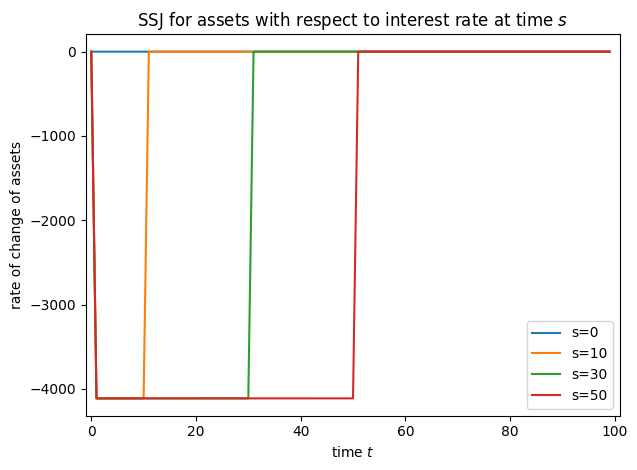

In [8]:
# plt.plot(out[0,50,:,30])
# plt.show()

# a_grid = make_exponential_grid(0., 40., 200, order=2.5)
# plt.plot(out[0][:,0,50])

plot_SSJ(out[1], [0, 10, 30, 50], "assets", "interest rate")